# Regional economic-sentiment index — Huila, Colombia

I build a sentiment index from regional economic news, classifying each item with an LLM (Google Gemini) and aggregating the result over time.

**Own approach:** LLM classification (reads context, not just keywords) · regional scope · stated bias.
**Index method:** simple — (% positive − % negative) per period.
**v3 approach:** the sentiment index and charts are calculated on a **per-month basis** (selected via `mes`), while the labeled dataset (`data_labeled.csv`) accumulates all historical news to train the classic NLP baseline.

> The news are in Spanish (regional outlets), so the classification prompt is kept in Spanish; all analysis code and notes are in English.


In [1]:
# Configuration: target month to analyze and chart (format: YYYY-MM)
mes = "2026-08"

# News dataset produced by a separate scraping step (kept private).
# Columns come from the source in Spanish: año, mes, día, medio, titulo, contenido, url.
import os
import pandas as pd

df = pd.read_excel("data.xlsx")
df["date"] = pd.to_datetime(dict(year=df["año"], month=df["mes"], day=df["día"]))

# Data cleaning: the scraper caught some articles twice (pagination overlap). Drop duplicates.
df = df.drop_duplicates(subset="url").reset_index(drop=True)
df = df[["date", "medio", "titulo", "contenido"]].sort_values("date").reset_index(drop=True)

print(f"{len(df)} unique news items in total: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


93 unique news items in total: 2026-08-04 to 2026-09-04


,date,medio,titulo,contenido
0,2026-08-04,Diario del Huila,"Exportaciones de Colombia crecieron 7%, pero c...","Exportaciones de Colombia crecieron 7%, pero c..."
1,2026-08-04,Diario del Huila,"Actividad económica del país creció 2,2% en el...","Actividad económica del país creció 2,2% en el..."
2,2026-08-04,Diario del Huila,Papa baja de precio y alimentos básicos mantie...,Papa baja de precio y alimentos básicos mantie...
3,2026-08-05,Diario del Huila,Colombia exportó más servicios empresariales y...,Colombia exportó más servicios empresariales y...
4,2026-08-06,Diario del Huila,Colombia en alerta: ACP advierte riesgo de des...,Colombia en alerta: ACP advierte riesgo de des...


In [2]:
# Connect to Gemini. The API key is requested at runtime and never stored in the notebook.
from google import genai
import getpass

client = genai.Client(api_key=getpass.getpass("Paste your Gemini API key: "))
print("Client ready")


Client ready


In [3]:
# Classify the economic sentiment of a news item as positive / negative / neutral.
# Prompt is in Spanish because the news are in Spanish; the LLM reads the full context.
def classify_sentiment(title, body):
    prompt = f"""Clasifica el SENTIMIENTO ECONÓMICO de esta noticia según su impacto sobre la economía regional.
Responde SOLO una palabra: positivo, negativo o neutral.

- positivo: mejora económica (crecimiento, empleo, inversión, exportaciones al alza).
- negativo: deterioro (caída, desempleo, cierre, inflación, crisis).
- neutral: informativo sin dirección clara, o efectos mixtos.

Título: {title}
Contenido: {body[:800]}

Respuesta (una palabra):"""
    r = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    return r.text.strip().lower()

# Quick check on the first item
classify_sentiment(df.loc[0, "titulo"], df.loc[0, "contenido"])


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


'neutral'

In [4]:
# Classify news items with Gemini for the selected month.
# If data_labeled.csv exists, load existing labels so we only call Gemini for unclassified items.
import time

if os.path.exists("data_labeled.csv"):
    existing_labels = pd.read_csv("data_labeled.csv").set_index("titulo")["sentiment"].to_dict()
else:
    existing_labels = {}

# Filter dataset for the selected month
df_month = df[df["date"].dt.to_period("M") == mes].copy().reset_index(drop=True)
print(f"Selected month: {mes} ({len(df_month)} news items)")

# Classify items in the selected month (skip if already labeled)
labels = []
for i, row in df_month.iterrows():
    title = row["titulo"]
    if title in existing_labels and pd.notna(existing_labels[title]):
        s = existing_labels[title]
        print(f"{i+1}/{len(df_month)}  ->  {s:9} (cached) | {title[:55]}")
    else:
        s = classify_sentiment(title, row["contenido"])
        existing_labels[title] = s
        print(f"{i+1}/{len(df_month)}  ->  {s:9} (new)    | {title[:55]}")
        time.sleep(0.5)
    labels.append(s)

df_month["sentiment"] = labels
print("\nSentiment distribution for", mes)
df_month["sentiment"].value_counts()


Selected month: 2026-08 (76 news items)
1/76  ->  neutral   (cached) | Exportaciones de Colombia crecieron 7%, pero café y flo
2/76  ->  positivo  (cached) | Actividad económica del país creció 2,2% en el primer t
3/76  ->  positivo  (cached) | Papa baja de precio y alimentos básicos mantienen estab
4/76  ->  positivo  (cached) | Colombia exportó más servicios empresariales y de trans
5/76  ->  negativo  (cached) | Colombia en alerta: ACP advierte riesgo de desabastecim
6/76  ->  positivo  (cached) | Bolsa de Colombia propone reformas para impulsar la inv
7/76  ->  negativo  (cached) | Corficolombiana prevé caída del sector agropecuario en 
8/76  ->  negativo  (cached) | Precios al productor cayeron 1,42% en julio de 2026.
9/76  ->  negativo  (cached) | Retos energéticos del nuevo Gobierno de Colombia.
10/76  ->  negativo  (cached) | Petro deja a De la Espriella una economía con desafíos.
11/76  ->  negativo  (cached) | Inflación de julio: expertos prevén que llegue al 6,30 
12/76  -> 

sentiment
negativo    35
positivo    30
neutral     11
Name: count, dtype: int64

In [5]:
# Persist the accumulated labeled dataset (all months combined).
# The companion notebook (classic_nlp_tfidf.ipynb) trains on this full historical dataset.
df["sentiment"] = df["titulo"].map(existing_labels)
df_labeled = df.dropna(subset=["sentiment"]).copy()
df_labeled[["date", "medio", "titulo", "contenido", "sentiment"]].to_csv("data_labeled.csv", index=False)
print(f"Saved data_labeled.csv — {len(df_labeled)} total labeled items accumulated")


Saved data_labeled.csv — 93 total labeled items accumulated


In [6]:
# Index = (% positive - % negative), scaled -100 (all bad) to +100 (all good).
def sentiment_index(group):
    n = len(group)
    return (group.eq("positivo").sum() - group.eq("negativo").sum()) / n * 100

overall = sentiment_index(df_month["sentiment"])
year_str, month_str = mes.split("-")
month_name = pd.to_datetime(mes).strftime("%B %Y")
print(f"Sentiment index — Huila, {month_name}: {overall:+.1f}")

# Daily index to see the evolution across the selected month.
daily = df_month.groupby(df_month["date"].dt.date)["sentiment"].apply(sentiment_index)
daily


Sentiment index — Huila, August 2026: -6.6


date
2026-08-04     66.666667
2026-08-05    100.000000
2026-08-06    -50.000000
2026-08-07    -100.000000
2026-08-09    -50.000000
2026-08-10     50.000000
2026-08-11    -50.000000
2026-08-12     40.000000
2026-08-13    -50.000000
2026-08-14     33.333333
2026-08-15      0.000000
2026-08-17    -100.000000
2026-08-18    -100.000000
2026-08-19    -33.333333
2026-08-20     33.333333
2026-08-21     33.333333
2026-08-22    -50.000000
2026-08-23    100.000000
2026-08-24    -42.857143
2026-08-25    -20.000000
2026-08-26      0.000000
2026-08-27      0.000000
2026-08-28      0.000000
2026-08-29    100.000000
2026-08-31    100.000000
Name: sentiment, dtype: float64

Saved sentiment_index_08_2026.png


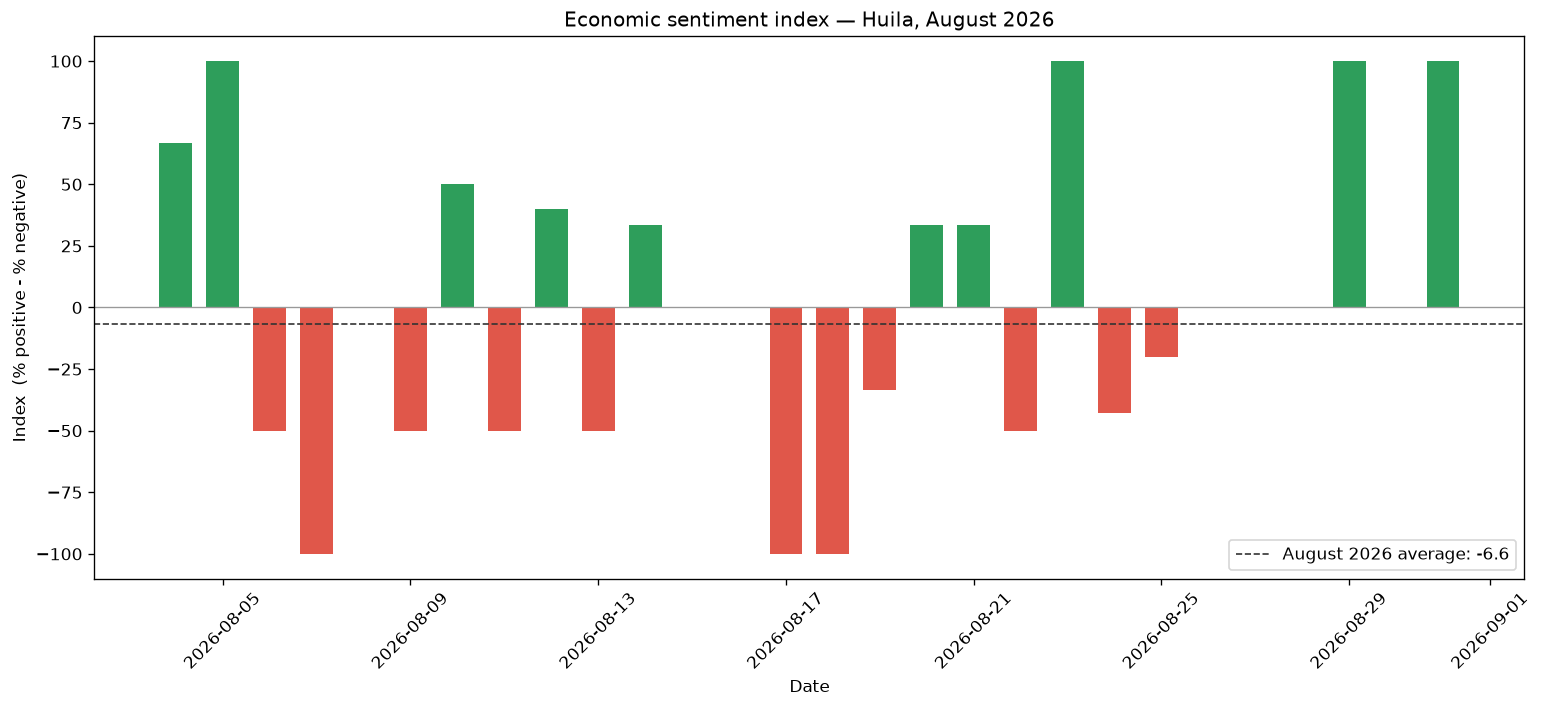

In [12]:
# Daily index: green bars = positive days, red = negative; dashed line = monthly average.
import matplotlib.pyplot as plt

chart_filename = f"sentiment_index_{month_str}_{year_str}.png"

fig, ax = plt.subplots(figsize=(13, 6))
colors = ["#2e9e5b" if v >= 0 else "#e0574a" for v in daily.values]
ax.bar(daily.index, daily.values, color=colors, width=0.7)
ax.axhline(overall, color="#333", linestyle="--", linewidth=1, label=f"{month_name} average: {overall:+.1f}")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_title(f"Economic sentiment index — Huila, {month_name}")
ax.set_ylabel("Index  (% positive - % negative)"); ax.set_xlabel("Date")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig.savefig(chart_filename, dpi=120, bbox_inches="tight")
print(f"Saved {chart_filename}")


In [8]:
# OPTIONAL — aggregate weekly to smooth the index across the selected month.
# The daily view above can be volatile if some days have few news items.
period = "W"          # "W" = weekly
agg = df_month.groupby(df_month["date"].dt.to_period(period))["sentiment"].apply(sentiment_index)
agg.index = agg.index.astype(str)
print(agg)


date
2026-08-03/2026-08-09    -16.666667
2026-08-10/2026-08-16      5.555556
2026-08-17/2026-08-23    -16.666667
2026-08-24/2026-08-30    -11.538462
2026-08-31/2026-09-06    100.000000
Name: sentiment, dtype: float64


Saved sentiment_index_weekly_08_2026.png


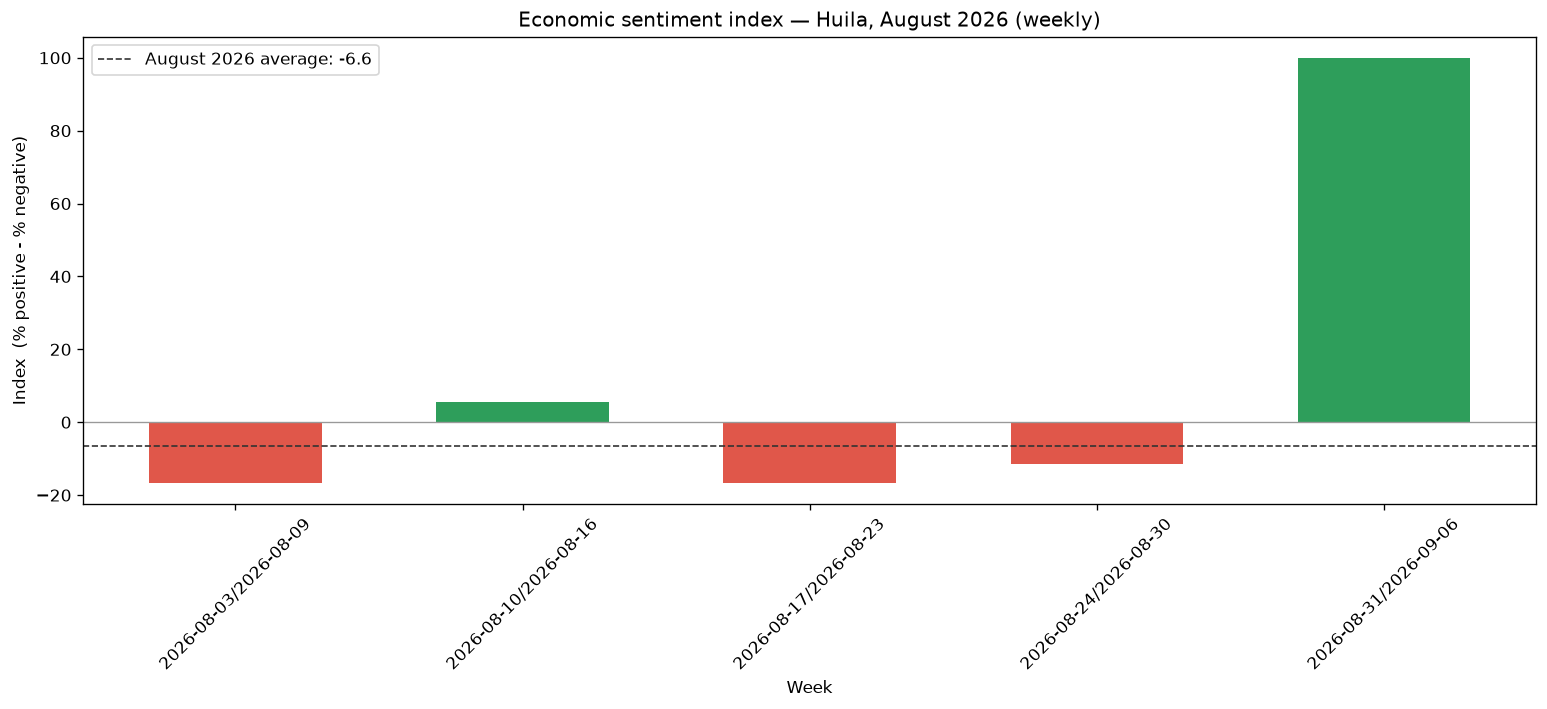

In [14]:
# Aggregated index chart (weekly) for the selected month. Uses `agg` from above.
import matplotlib.pyplot as plt

weekly_chart_filename = f"sentiment_index_weekly_{month_str}_{year_str}.png"

fig, ax = plt.subplots(figsize=(13, 6))
colors = ["#2e9e5b" if v >= 0 else "#e0574a" for v in agg.values]
ax.bar(agg.index, agg.values, color=colors, width=0.6)
ax.axhline(overall, color="#333", linestyle="--", linewidth=1, label=f"{month_name} average: {overall:+.1f}")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_title(f"Economic sentiment index — Huila, {month_name} (weekly)")
ax.set_ylabel("Index  (% positive - % negative)"); ax.set_xlabel("Week")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig.savefig(weekly_chart_filename, dpi=120, bbox_inches="tight")
print(f"Saved {weekly_chart_filename}")
